To install a Python library, you can use the `pip install` command. For example, to install the `numpy` library, you would run the following in a code cell:

In [ ]:
!pip install numpy

You can also install multiple libraries at once, or a specific version of a library:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving world_happiness_2026.csv to world_happiness_2026.csv


In [ ]:
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("First 5 rows:")
print(df.head())

First 5 rows:
   rank     country                       region  score  gdp_per_capita  \
0     1     Finland               Western Europe  7.764           1.892   
1     2     Iceland               Western Europe  7.701           1.874   
2     3     Denmark               Western Europe  7.688           1.887   
3     4  Costa Rica  Latin America and Caribbean  7.439           1.254   
4     5      Sweden               Western Europe  7.401           1.878   

   social_support  healthy_life_expectancy  freedom  generosity  corruption  
0           1.581                    0.952    0.670       0.186       0.498  
1           1.611                    0.959    0.662       0.269       0.512  
2           1.562                    0.948    0.665       0.211       0.495  
3           1.421                    0.891    0.631       0.178       0.312  
4           1.501                    0.952    0.658       0.224       0.481  


In [ ]:
print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistics:")
df.describe()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   rank                     147 non-null    int64  
 1   country                  147 non-null    object 
 2   region                   147 non-null    object 
 3   score                    147 non-null    float64
 4   gdp_per_capita           147 non-null    float64
 5   social_support           147 non-null    float64
 6   healthy_life_expectancy  147 non-null    float64
 7   freedom                  147 non-null    float64
 8   generosity               147 non-null    float64
 9   corruption               147 non-null    float64
dtypes: float64(7), int64(1), object(2)
memory usage: 11.6+ KB

Missing Values:
rank                       0
country                    0
region                     0
score                      0
gdp_per_capita             0
social_

,rank,score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,corruption
count,147.000000,147.000000,147.000000,147.000000,147.000000,147.000000,147.000000,147.000000
mean,74.000000,5.205694,1.043095,1.122279,0.694075,0.457673,0.162884,0.161340
std,42.579338,1.393472,0.588589,0.291444,0.212594,0.135096,0.054843,0.135871
min,1.000000,1.446000,0.171000,0.341000,0.251000,0.071000,0.061000,0.011000
25%,37.500000,3.901000,0.471000,0.851000,0.491000,0.371000,0.131000,0.051000
50%,74.000000,5.431000,1.021000,1.181000,0.771000,0.481000,0.161000,0.121000
75%,110.500000,6.291000,1.596000,1.361000,0.881000,0.561000,0.196000,0.246000
max,147.000000,7.764000,2.121000,1.611000,0.961000,0.671000,0.301000,0.512000


In [ ]:
# Remove duplicates
df = df.drop_duplicates()

# Fill missing numeric values
df.fillna(df.mean(numeric_only=True), inplace=True)

In [ ]:
def happiness_category(score):
    if score < 5:
        return "Low"
    elif score < 7:
        return "Medium"
    else:
        return "High"

df['Happiness_Level'] = df['score'].apply(happiness_category)

print(df['Happiness_Level'].value_counts())

Happiness_Level
Medium    81
Low       55
High      11
Name: count, dtype: int64


In [ ]:
print("\nTop 10 Happiest Countries:")
print(df.sort_values(by='score', ascending=False).head(10)[['country', 'score']])

print("\nBottom 10 Countries:")
print(df.sort_values(by='score').head(10)[['country', 'score']])


Top 10 Happiest Countries:
       country  score
0      Finland  7.764
1      Iceland  7.701
2      Denmark  7.688
3   Costa Rica  7.439
4       Sweden  7.401
5       Norway  7.392
6  Netherlands  7.319
7       Israel  7.234
8   Luxembourg  7.228
9  Switzerland  7.201

Bottom 10 Countries:
         country  score
146  Afghanistan  1.446
145       Rwanda  2.661
141      Lebanon  2.707
144  South Sudan  2.711
143     Congo DR  2.761
142     Zimbabwe  2.811
140        Yemen  2.891
139        Haiti  3.181
138       Guinea  3.201
137         Togo  3.221


In [ ]:
region_analysis = df.groupby('region').agg({
    'score': 'mean',
    'gdp_per_capita': 'mean',
    'social_support': 'mean',
    'freedom': 'mean'
}).sort_values(by='score', ascending=False)

print("\nRegion-wise Analysis:")
print(region_analysis)


Region-wise Analysis:
                                       score  gdp_per_capita  social_support  \
region                                                                         
Western Europe                      6.987167        1.863944        1.479389   
North America and ANZ               6.969000        1.843500        1.513500   
Central and Eastern Europe          6.532083        1.499333        1.351583   
East Asia                           6.099200        1.663000        1.369000   
Commonwealth of Independent States  5.757000        1.241000        1.283000   
Latin America and Caribbean         5.706563        1.141188        1.242875   
Southeast Asia                      5.694333        1.273222        1.262111   
Middle East and North Africa        5.037187        1.084250        1.119125   
South Asia                          4.816833        0.816000        1.051000   
Sub-Saharan Africa                  3.962071        0.498857        0.845643   

                

In [ ]:
correlation = df.corr(numeric_only=True)

print("\nCorrelation with Happiness Score:")
print(correlation['score'].sort_values(ascending=False))


Correlation with Happiness Score:
score                      1.000000
social_support             0.981427
freedom                    0.944474
healthy_life_expectancy    0.913300
gdp_per_capita             0.897957
corruption                 0.877939
generosity                 0.257694
rank                      -0.986286
Name: score, dtype: float64


In [ ]:
scores = np.array(df['score'])

print("\nNumPy Stats:")
print("Mean:", np.mean(scores))
print("Median:", np.median(scores))
print("Std Dev:", np.std(scores))


NumPy Stats:
Mean: 5.205693877551021
Median: 5.431
Std Dev: 1.388724088278113


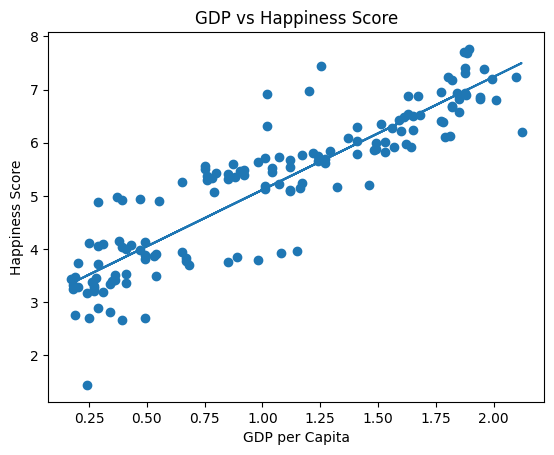

In [ ]:
plt.figure()

plt.scatter(df['gdp_per_capita'], df['score'])

# Add trend line
z = np.polyfit(df['gdp_per_capita'], df['score'], 1)
p = np.poly1d(z)
plt.plot(df['gdp_per_capita'], p(df['gdp_per_capita']))

plt.title("GDP vs Happiness Score")
plt.xlabel("GDP per Capita")
plt.ylabel("Happiness Score")

plt.show()

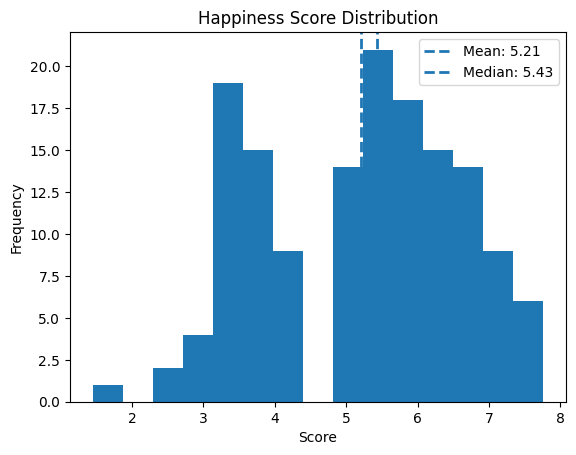

In [ ]:
plt.figure()

plt.hist(df['score'], bins=15)

# Mean and Median lines
mean_val = df['score'].mean()
median_val = df['score'].median()

plt.axvline(mean_val, linestyle='dashed', linewidth=2, label=f"Mean: {mean_val:.2f}")
plt.axvline(median_val, linestyle='dashed', linewidth=2, label=f"Median: {median_val:.2f}")

plt.title("Happiness Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")

plt.legend()
plt.show()

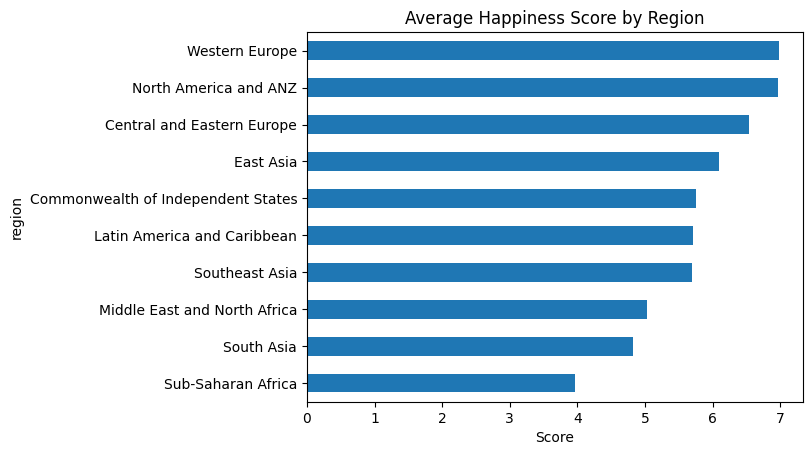

In [ ]:
region_scores = df.groupby('region')['score'].mean()

plt.figure()
region_scores.sort_values().plot(kind='barh')
plt.title("Average Happiness Score by Region")
plt.xlabel("Score")
plt.show()

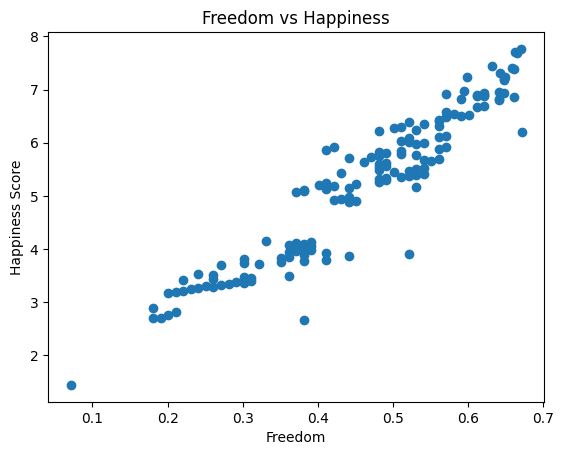

In [ ]:
plt.figure()
plt.scatter(df['freedom'], df['score'])
plt.title("Freedom vs Happiness")
plt.xlabel("Freedom")
plt.ylabel("Happiness Score")
plt.show()

In [ ]:
df.to_csv('processed_happiness_data.csv', index=False)

from google.colab import files
files.download('processed_happiness_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>